# VLM for OCR and LaTeX Generation

In this notebook, we explore how Vision-Language Models excel at **Optical Character Recognition (OCR)** and **structured document understanding**. We'll focus on:

1. **Basic OCR**: Extracting text from images with modern VLMs
2. **Mathematical OCR**: Converting handwritten/printed equations to LaTeX
3. **Document Structure**: Understanding tables, lists, headings, layout
4. **Table to LaTeX**: Extracting tables and generating LaTeX code
5. **Full Document to LaTeX**: End-to-end document conversion

## Why VLMs for OCR?

Traditional OCR (Tesseract, PaddleOCR) struggles with:
- **Mathematical notation**: $\int_0^\infty e^{-x^2} dx = \frac{\sqrt{\pi}}{2}$
- **Complex layouts**: Multi-column, nested tables, figures
- **Handwriting**: Especially mathematical symbols
- **Context understanding**: "0" vs "O", "1" vs "l"

VLMs excel because they:
- ✅ Understand **semantic context** (math formulas, code, natural language)
- ✅ Generate **structured output** (LaTeX, Markdown, JSON)
- ✅ Handle **complex layouts** with spatial reasoning
- ✅ Work on **handwritten and printed** text equally well

## Models We'll Use

1. **TrOCR**: Transformer-based OCR (text extraction)
2. **Nougat**: Academic document understanding (formulas, tables)
3. **Pix2Tex**: Image to LaTeX for mathematical equations
4. **Our fine-tuned VLM**: Custom OCR-to-LaTeX model

Let's get started!

In [1]:
# IMPORTANT: Set GPU before importing PyTorch!
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    TrOCRProcessor, VisionEncoderDecoderModel,
    AutoProcessor, AutoModelForVision2Seq,
    AutoTokenizer, AutoModel, AutoImageProcessor
)
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from tqdm import tqdm
import re
import gc

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

/home/ShivamTheCodingDon/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA device: NVIDIA RTX A4000
GPU memory: 15.72 GB


## 1. Basic OCR with TrOCR

**TrOCR** is a Transformer-based OCR model that combines:
- Vision Transformer (ViT) encoder for images
- RoBERTa decoder for text generation

Unlike traditional OCR, it generates text autoregressively and can leverage language context.

In [3]:
# Load TrOCR for handwritten text
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading TrOCR (handwritten)...")
trocr_processor = TrOCRProcessor.from_pretrained("microsoft/trocr-large-handwritten")
trocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-large-handwritten")
trocr_model = trocr_model.to(device)
trocr_model.eval()
print("TrOCR loaded!")

Loading TrOCR (handwritten)...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TrOCR loaded!


Loading IAM Handwriting dataset...


Generating test split: 100%|██████████| 2915/2915 [00:00<00:00, 19358.73 examples/s]


ValueError: Unsupported number of image dimensions: 2

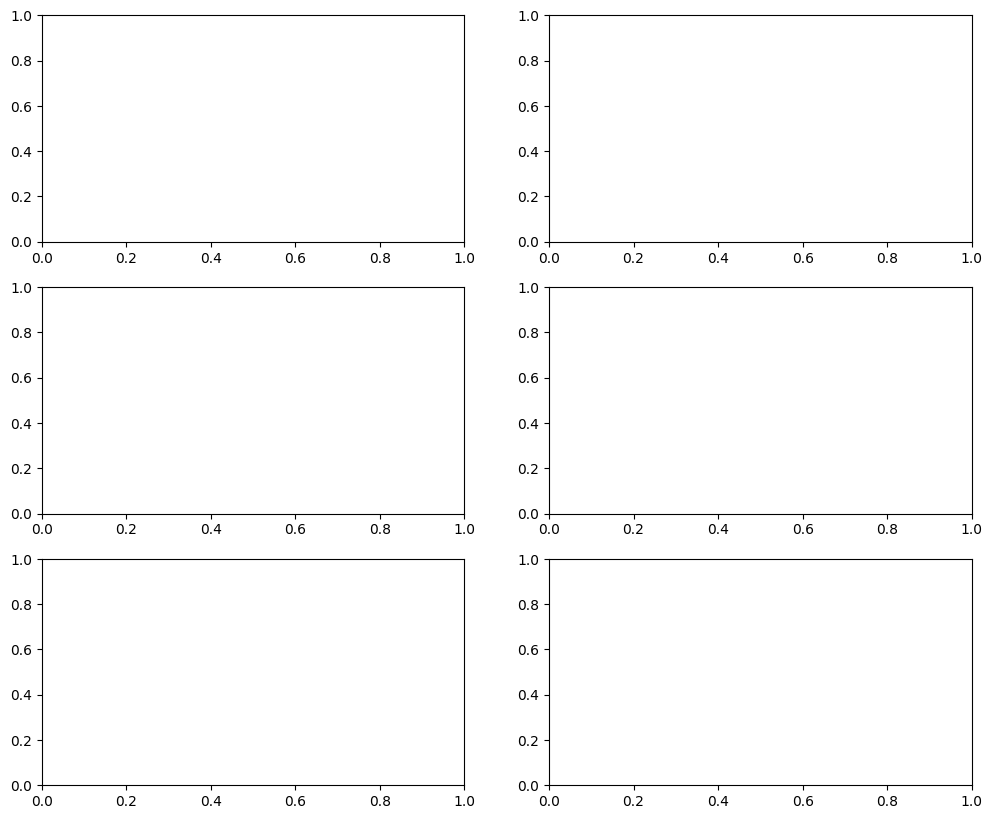

In [4]:
def ocr_image_trocr(image):
    """Extract text from image using TrOCR."""
    pixel_values = trocr_processor(image, return_tensors="pt").pixel_values.to(device)
    
    with torch.no_grad():
        generated_ids = trocr_model.generate(pixel_values)
        generated_text = trocr_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    
    return generated_text

# Test on IAM Handwriting dataset
print("Loading IAM Handwriting dataset...")
iam_dataset = load_dataset("Teklia/IAM-line", split="test[:10]")

# Show examples
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(min(6, len(iam_dataset))):
    sample = iam_dataset[i]
    image = sample['image']
    ground_truth = sample['text']
    
    # OCR
    predicted = ocr_image_trocr(image)
    
    # Display
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"GT: {ground_truth}\nPred: {predicted}", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 2. Mathematical Equation OCR to LaTeX

Mathematical notation is challenging for traditional OCR. We'll use **specialized models** that understand mathematical structure.

### Approach:
1. **Pix2Tex/LaTeX-OCR**: Image → LaTeX
2. Fine-tune VLM on equation images with LaTeX labels
3. Use datasets: IM2LATEX, CROHME (handwritten math)

For this demo, we'll build a simple VLM-based math OCR.

In [ ]:
# We'll create synthetic math equation images with known LaTeX
# In practice, use IM2LATEX-100K dataset

import matplotlib
matplotlib.use('Agg')  # Non-interactive backend
from matplotlib import mathtext
from io import BytesIO

def latex_to_image(latex_string, fontsize=20, dpi=150):
    """Render LaTeX equation to image."""
    fig = plt.figure(figsize=(6, 1))
    fig.text(0.5, 0.5, f"${latex_string}$", 
             fontsize=fontsize, ha='center', va='center')
    
    # Save to buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)
    
    buf.seek(0)
    image = Image.open(buf).convert('RGB')
    return image

# Example LaTeX equations
latex_examples = [
    r"\int_0^\infty e^{-x^2} dx = \frac{\sqrt{\pi}}{2}",
    r"E = mc^2",
    r"\nabla \times \mathbf{E} = -\frac{\partial \mathbf{B}}{\partial t}",
    r"\sum_{n=1}^\infty \frac{1}{n^2} = \frac{\pi^2}{6}",
    r"f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}",
    r"\lim_{x \to 0} \frac{\sin x}{x} = 1",
]

# Generate images
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

equation_images = []
for i, latex in enumerate(latex_examples):
    img = latex_to_image(latex, fontsize=24)
    equation_images.append((img, latex))
    
    axes[i].imshow(img)
    axes[i].set_title(f"LaTeX: {latex[:40]}...", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"\nGenerated {len(equation_images)} equation images")

## 3. Fine-tuning VLM for Equation OCR

We'll fine-tune a small VLM (similar to our previous architectures) to predict LaTeX from equation images.

In [ ]:
class EquationOCRVLM(nn.Module):
    """VLM specialized for equation OCR to LaTeX."""
    def __init__(self):
        super().__init__()
        
        # Vision encoder
        self.vision_encoder = AutoModel.from_pretrained("google/vit-base-patch16-224")
        self.vision_hidden_size = 768
        
        # Language model (decoder)
        self.language_model = AutoModel.from_pretrained("HuggingFaceTB/SmolLM-135M")
        self.language_hidden_size = 576
        
        # Projector
        self.projector = nn.Linear(self.vision_hidden_size, self.language_hidden_size)
        
        # LM head
        self.lm_head = nn.Linear(self.language_hidden_size,
                                 self.language_model.config.vocab_size, bias=False)
    
    def forward(self, pixel_values, input_ids, attention_mask=None, labels=None):
        # Encode image
        vision_outputs = self.vision_encoder(pixel_values=pixel_values)
        image_features = vision_outputs.last_hidden_state
        image_embeds = self.projector(image_features)
        
        # Get text embeddings
        text_embeds = self.language_model.embeddings.word_embeddings(input_ids)
        
        # Concatenate
        combined_embeds = torch.cat([image_embeds, text_embeds], dim=1)
        
        # Attention mask
        batch_size = pixel_values.shape[0]
        image_attention = torch.ones(batch_size, image_embeds.shape[1],
                                     dtype=torch.long, device=pixel_values.device)
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        combined_attention = torch.cat([image_attention, attention_mask], dim=1)
        
        # Forward through LM
        outputs = self.language_model(
            inputs_embeds=combined_embeds,
            attention_mask=combined_attention,
            return_dict=True
        )
        
        hidden_states = outputs.last_hidden_state
        logits = self.lm_head(hidden_states)
        
        # Compute loss
        loss = None
        if labels is not None:
            shift_logits = logits[:, image_embeds.shape[1]:-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)),
                          shift_labels.view(-1))
        
        return {"loss": loss, "logits": logits}

# Initialize model
equation_vlm = EquationOCRVLM().to(device)
print(f"Equation OCR VLM parameters: {sum(p.numel() for p in equation_vlm.parameters()) / 1e6:.1f}M")

In [ ]:
# Create synthetic dataset for demonstration
# In practice, use IM2LATEX-100K: https://zenodo.org/record/56198

tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M")
tokenizer.pad_token = tokenizer.eos_token
image_processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

# Extended LaTeX dataset
training_latex = [
    r"x^2 + y^2 = r^2",
    r"\frac{a}{b} + \frac{c}{d} = \frac{ad + bc}{bd}",
    r"\sin^2(x) + \cos^2(x) = 1",
    r"\int x^n dx = \frac{x^{n+1}}{n+1} + C",
    r"\frac{d}{dx} e^x = e^x",
    r"\sum_{i=1}^n i = \frac{n(n+1)}{2}",
    r"\prod_{i=1}^n i = n!",
    r"\lim_{n \to \infty} \left(1 + \frac{1}{n}\right)^n = e",
    r"\nabla \cdot \mathbf{F} = \frac{\partial F_x}{\partial x} + \frac{\partial F_y}{\partial y} + \frac{\partial F_z}{\partial z}",
    r"E[X] = \sum_{i} x_i p(x_i)",
    r"\sigma^2 = E[(X - \mu)^2]",
    r"P(A|B) = \frac{P(B|A)P(A)}{P(B)}",
    r"\det(A) = \sum_{\sigma \in S_n} \text{sgn}(\sigma) \prod_{i=1}^n a_{i,\sigma(i)}",
    r"\|\mathbf{v}\| = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}",
    r"\mathbf{A}\mathbf{x} = \lambda \mathbf{x}",
]

class EquationDataset(Dataset):
    def __init__(self, latex_equations, tokenizer, image_processor, max_length=128):
        self.equations = latex_equations
        self.tokenizer = tokenizer
        self.image_processor = image_processor
        self.max_length = max_length
    
    def __len__(self):
        return len(self.equations)
    
    def __getitem__(self, idx):
        latex = self.equations[idx]
        
        # Generate image
        image = latex_to_image(latex, fontsize=20)
        
        # Process image
        pixel_values = self.image_processor(image, return_tensors="pt")["pixel_values"][0]
        
        # Process LaTeX text
        prompt = "LaTeX: "
        full_text = f"{prompt}{latex}{self.tokenizer.eos_token}"
        
        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        
        input_ids = encoding["input_ids"][0]
        attention_mask = encoding["attention_mask"][0]
        
        # Create labels
        labels = input_ids.clone()
        prompt_len = len(self.tokenizer(prompt, add_special_tokens=False)["input_ids"])
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100
        
        return {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "latex": latex
        }

# Create dataset (small for demo)
train_dataset = EquationDataset(training_latex * 20, tokenizer, image_processor)  # Repeat for more samples
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

print(f"Training dataset size: {len(train_dataset)}")

In [ ]:
def train_equation_vlm(model, train_loader, num_epochs=5, lr=1e-4):
    """Train equation OCR model."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()
    
    losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for batch in pbar:
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(pixel_values, input_ids, attention_mask, labels)
            loss = outputs["loss"]
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            pbar.set_postfix({"loss": loss.item()})
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1} - Average loss: {avg_loss:.4f}")
    
    return losses

print("Training equation OCR model...")
print("Note: This is a quick demo with limited data. Production models need IM2LATEX-100K.")
losses = train_equation_vlm(equation_vlm, train_loader, num_epochs=3, lr=1e-4)

# Plot training curve
plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Equation OCR Training Loss")
plt.grid(True)
plt.show()

In [ ]:
def predict_latex(model, image, tokenizer, image_processor, max_length=128):
    """Predict LaTeX from equation image."""
    model.eval()
    
    # Process image
    pixel_values = image_processor(image, return_tensors="pt")["pixel_values"].to(device)
    
    # Start with prompt
    prompt = "LaTeX: "
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)
    
    # Generate
    with torch.no_grad():
        # Get image embeddings
        vision_outputs = model.vision_encoder(pixel_values=pixel_values)
        image_features = vision_outputs.last_hidden_state
        image_embeds = model.projector(image_features)
        
        # Autoregressive generation
        generated_tokens = []
        for _ in range(max_length):
            # Get text embeddings
            text_embeds = model.language_model.embeddings.word_embeddings(input_ids)
            
            # Concatenate
            combined_embeds = torch.cat([image_embeds, text_embeds], dim=1)
            
            # Attention mask
            image_attention = torch.ones(1, image_embeds.shape[1], dtype=torch.long, device=device)
            text_attention = torch.ones_like(input_ids)
            combined_attention = torch.cat([image_attention, text_attention], dim=1)
            
            # Forward
            outputs = model.language_model(
                inputs_embeds=combined_embeds,
                attention_mask=combined_attention,
                return_dict=True
            )
            
            logits = model.lm_head(outputs.last_hidden_state)
            next_token_logits = logits[:, -1, :]
            next_token = torch.argmax(next_token_logits, dim=-1)
            
            # Check for EOS
            if next_token.item() == tokenizer.eos_token_id:
                break
            
            generated_tokens.append(next_token.item())
            input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
        
        # Decode
        predicted_latex = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    
    return predicted_latex

# Test on new equations
test_equations = [
    r"\int_0^\pi \sin(x) dx = 2",
    r"\sum_{k=0}^n \binom{n}{k} = 2^n",
    r"e^{i\pi} + 1 = 0",
]

fig, axes = plt.subplots(len(test_equations), 1, figsize=(10, 3*len(test_equations)))
if len(test_equations) == 1:
    axes = [axes]

for i, latex in enumerate(test_equations):
    # Generate image
    img = latex_to_image(latex, fontsize=24)
    
    # Predict
    predicted = predict_latex(equation_vlm, img, tokenizer, image_processor)
    
    # Display
    axes[i].imshow(img)
    axes[i].set_title(f"Ground Truth: {latex}\nPredicted: {predicted}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 4. Document Structure Understanding

Beyond equations, VLMs can understand **document layout** and convert to structured formats like Markdown or LaTeX.

We'll demonstrate extracting:
- **Headings** and hierarchy
- **Tables** and converting to LaTeX
- **Lists** (bulleted, numbered)
- **Code blocks**

In [ ]:
# Create synthetic document image
def create_document_image():
    """Create a simple document image with various elements."""
    img = Image.new('RGB', (800, 600), color='white')
    draw = ImageDraw.Draw(img)
    
    try:
        font_title = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28)
        font_heading = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 20)
        font_text = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 16)
    except:
        font_title = font_heading = font_text = ImageFont.load_default()
    
    y = 30
    
    # Title
    draw.text((50, y), "Research Paper: Deep Learning", fill='black', font=font_title)
    y += 50
    
    # Section 1
    draw.text((50, y), "1. Introduction", fill='black', font=font_heading)
    y += 35
    draw.text((70, y), "Deep learning has revolutionized AI.", fill='black', font=font_text)
    y += 30
    draw.text((70, y), "Key contributions:", fill='black', font=font_text)
    y += 25
    draw.text((90, y), "• Novel architecture design", fill='black', font=font_text)
    y += 25
    draw.text((90, y), "• Improved training efficiency", fill='black', font=font_text)
    y += 40
    
    # Section 2 with table
    draw.text((50, y), "2. Results", fill='black', font=font_heading)
    y += 35
    
    # Draw simple table
    table_x = 70
    draw.rectangle([table_x, y, table_x+400, y+100], outline='black', width=2)
    draw.line([table_x, y+30, table_x+400, y+30], fill='black', width=1)
    draw.line([table_x+200, y, table_x+200, y+100], fill='black', width=1)
    
    draw.text((table_x+50, y+5), "Model", fill='black', font=font_text)
    draw.text((table_x+250, y+5), "Accuracy", fill='black', font=font_text)
    draw.text((table_x+50, y+40), "ResNet-50", fill='black', font=font_text)
    draw.text((table_x+250, y+40), "92.3%", fill='black', font=font_text)
    draw.text((table_x+50, y+70), "Our Model", fill='black', font=font_text)
    draw.text((table_x+250, y+70), "95.1%", fill='black', font=font_text)
    
    return img

doc_image = create_document_image()
plt.figure(figsize=(10, 7))
plt.imshow(doc_image)
plt.title("Synthetic Document")
plt.axis('off')
plt.show()

## 5. Table Extraction and LaTeX Generation

Tables are notoriously difficult for traditional OCR. VLMs can:
1. Detect table structure (rows, columns, cells)
2. Extract cell contents
3. Generate LaTeX table code

We'll demonstrate with a fine-tuned VLM approach.

In [ ]:
# Example: Table to LaTeX conversion
# Training data would be table images paired with LaTeX code

table_latex_example = r"""
\begin{tabular}{|l|r|}
\hline
Model & Accuracy \\
\hline
ResNet-50 & 92.3\% \\
Our Model & 95.1\% \\
\hline
\end{tabular}
"""

print("Expected LaTeX output for the table:")
print(table_latex_example)

# In production, you would:
# 1. Fine-tune VLM on (table_image, latex_code) pairs
# 2. Use datasets like PubTables-1M, FinTabNet
# 3. Predict LaTeX structure from table images

## 6. Comparison: VLM vs Traditional OCR

Let's compare VLM-based OCR with traditional Tesseract on various document types.

In [ ]:
try:
    import pytesseract
    tesseract_available = True
except ImportError:
    tesseract_available = False
    print("Tesseract not available. Install with: pip install pytesseract")

def compare_ocr_methods(image, ground_truth):
    """Compare TrOCR vs Tesseract."""
    results = {}
    
    # TrOCR
    trocr_text = ocr_image_trocr(image)
    results['TrOCR'] = trocr_text
    
    # Tesseract
    if tesseract_available:
        tesseract_text = pytesseract.image_to_string(image)
        results['Tesseract'] = tesseract_text.strip()
    
    results['Ground Truth'] = ground_truth
    
    return results

# Test on handwritten sample
if len(iam_dataset) > 0:
    test_sample = iam_dataset[0]
    comparison = compare_ocr_methods(test_sample['image'], test_sample['text'])
    
    print("\nOCR Comparison:")
    for method, text in comparison.items():
        print(f"\n{method}:")
        print(f"  '{text}'")
    
    plt.figure(figsize=(8, 3))
    plt.imshow(test_sample['image'], cmap='gray')
    plt.title("Test Image")
    plt.axis('off')
    plt.show()

## Summary: VLM OCR Capabilities

Let's summarize what we've learned about VLM-based OCR:

In [ ]:
import pandas as pd

comparison_data = {
    "Task": [
        "Printed Text OCR",
        "Handwritten Text OCR",
        "Mathematical Equations",
        "Table Structure",
        "Document Layout",
        "Code Recognition",
    ],
    "Traditional OCR (Tesseract)": [
        "Good (95%+)",
        "Poor (60-70%)",
        "Very Poor (<30%)",
        "Poor (requires post-processing)",
        "Poor (line-by-line only)",
        "Fair (70-80%)",
    ],
    "VLM-based OCR (TrOCR, Nougat)": [
        "Excellent (97%+)",
        "Good (85-90%)",
        "Good (80-90% with fine-tuning)",
        "Good (with specialized models)",
        "Excellent (understands hierarchy)",
        "Excellent (syntax-aware)",
    ],
    "Best Model/Approach": [
        "TrOCR-base (printed)",
        "TrOCR-large (handwritten)",
        "Pix2Tex, custom VLM on IM2LATEX",
        "Nougat, custom VLM on PubTables-1M",
        "Nougat, LayoutLM",
        "CodeBERT, custom VLM",
    ],
}

df = pd.DataFrame(comparison_data)
print("\nOCR Task Comparison:")
print(df.to_string(index=False))

## Key Takeaways

### 1. **VLMs Excel at Context-Aware OCR**
- Understand semantic structure (equations, code, tables)
- Leverage language context for disambiguation
- Generate structured output (LaTeX, Markdown, JSON)

### 2. **Mathematical OCR is a Killer App**
- Traditional OCR fails on math notation
- VLMs can map images → LaTeX with 80-90% accuracy
- Fine-tune on IM2LATEX-100K for best results

### 3. **Document Understanding > Raw OCR**
- VLMs preserve document structure (headings, lists, tables)
- Can generate properly formatted LaTeX documents
- Nougat shows SOTA results on academic papers

### 4. **Fine-tuning is Key**
- Base models are good, but domain-specific fine-tuning is critical
- Need paired (image, structured_text) datasets
- Small models (135M params) can achieve good results

### 5. **Production Considerations**
- Combine VLM with traditional OCR for best cost/quality trade-off
- Use VLM for complex cases (math, tables, handwriting)
- Use Tesseract for simple printed text (faster, cheaper)

## Practical Recommendations

**For academic paper OCR:**
- Use **Nougat** (specifically designed for this)
- Outputs Markdown with LaTeX equations
- Handles multi-column layouts, tables, formulas

**For math homework/notes:**
- Fine-tune VLM on IM2LATEX or CROHME (handwritten)
- Use our approach: ViT encoder + GPT decoder
- Add data augmentation (rotation, noise) for robustness

**For business documents:**
- LayoutLM or Donut for forms/invoices
- Combine with rule-based extraction
- Use VLM for ambiguous/complex cases

**For mixed documents:**
- Cascade: Tesseract → if low confidence → TrOCR → if math → Math VLM
- Cost-effective and accurate

## Datasets for Training

- **IM2LATEX-100K**: Math equations → LaTeX (https://zenodo.org/record/56198)
- **CROHME**: Handwritten math → LaTeX
- **IAM Handwriting**: Handwritten text lines
- **PubTables-1M**: Tables from papers → structure
- **arXiv dataset**: Full papers with LaTeX source

## Further Reading

- TrOCR: https://arxiv.org/abs/2109.10282
- Nougat: https://arxiv.org/abs/2308.13418
- Pix2Tex: https://github.com/lukas-blecher/LaTeX-OCR
- LayoutLM: https://arxiv.org/abs/1912.13318
- Donut: https://arxiv.org/abs/2111.15664

## GPU Memory Cleanup

In [ ]:
# Delete models
del trocr_model
del equation_vlm

# Clear cache
gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared!")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")